**Question 1**:

Write a SQL query to display:

- customer name

- city

- signup date

Sort results by signup_date (latest first).


**Answer:**


In [ ]:
USE customer_db;
SELECT customer_name, city, signup_date
FROM customers
ORDER BY signup_date DESC;


**Output:**

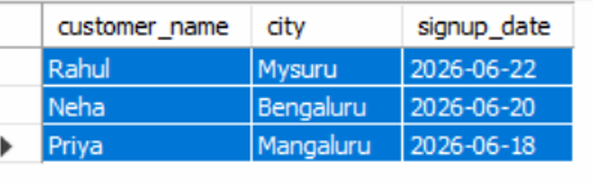

**Question 2**:

Find all orders placed in the last 30 days where:

 - total_amount > 5000

Sort by highest order value first.


**Answer: **


In [ ]:
USE customer_db;
CREATE TABLE orders (
    order_id INT PRIMARY KEY,
    customer_name VARCHAR(100),
    order_date DATE,
    total_amount DECIMAL(10,2)
);
INSERT INTO orders (order_id, customer_name, order_date, total_amount)
VALUES
(1, 'Neha', '2026-06-20', 6500),
(2, 'Rahul', '2026-06-15', 4500),
(3, 'Priya', '2026-06-10', 8000),
(4, 'Anil', '2026-05-18', 9000),
(5, 'Sneha', '2026-06-23', 5500);
SELECT *
FROM orders
WHERE order_date >= CURDATE() - INTERVAL 30 DAY
  AND total_amount > 5000
ORDER BY total_amount DESC;


**Output:**

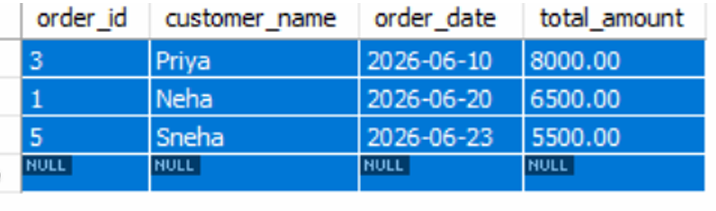

**Question 3**:

Explain:

a) What is the relational model?

b) Why are primary keys and foreign keys essential?

c) What problems does normalization solve?

 d) When might denormalization be preferred in analytics systems?


**Answer:**

a) What is the relational model?

-> The relational model is a database model that stores data in the form of tables (relations) consisting of rows and columns. Each table represents a specific entity, and relationships between tables are established using keys. It provides an efficient and organized way to store, retrieve, and manage data.

b) Why are primary keys and foreign keys essential?

- A Primary Key uniquely identifies each record in a table and does not allow duplicate or NULL values.
- A Foreign Key creates a relationship between two tables by referencing the primary key of another table.
- These keys maintain data integrity, prevent invalid data, and ensure consistency between related tables.

c) What problems does normalization solve?

-> Normalization organizes data into well-structured tables to:

- Reduce data redundancy (duplicate data).
- Prevent insertion, update, and deletion anomalies.
- Improve data consistency and integrity.
- Make database maintenance easier.

d) When might denormalization be preferred in analytics systems?

-> Denormalization is preferred in analytics and data warehousing systems when query performance is more important than reducing redundancy. By combining data into fewer tables, complex joins are reduced, making reporting and analytical queries faster, even though some duplicate data may exist.


**Question 4**:

Compare and contrast:
- Subqueries
- Joins
 - CTEs
Explain:

- When each should be used
 - Performance considerations
- Readability & maintainability trade-offs


**Answer:**

**Subqueries** are queries written inside another SQL query. They are useful when the result of one query is needed by another query, such as filtering or aggregating data. However, deeply nested or correlated subqueries can become difficult to read and may reduce performance because they may execute repeatedly.

**Joins** are used to combine data from two or more related tables based on a common column. They are the preferred choice when retrieving related information from multiple tables because they are generally faster and more efficient than subqueries. Joins are easy to understand for simple relationships, although they can become more complex when many tables are involved.

**CTEs (Common Table Expressions) **are temporary result sets created using the WITH clause. They help break complex SQL queries into smaller, more organized sections, making the code easier to read, debug, and maintain. While CTEs primarily improve readability, their performance depends on the database system and query optimizer.

**When to use each**: Use subqueries when one query depends on the result of another query. Use joins when combining related data from multiple tables. Use CTEs when writing complex queries that require better organization and readability.

**Performance considerations**: Joins usually provide better performance than subqueries for large datasets. Correlated subqueries can be slower because they execute repeatedly. CTEs mainly improve query organization, and their performance depends on how the database processes them.

**Readability and maintainability**: Subqueries can become difficult to understand when heavily nested. Joins are generally easy to read but can become complex when many tables are joined together. CTEs provide the best readability and maintainability because they divide complex logic into clear, reusable sections, making SQL queries easier to understand and modify.

**Question 5**:

Explain the difference between:

- Aggregation using GROUP BY
- Analytical calculations using window functions

Use an example to explain:
- Why window functions are critical in business analytics.


**Answer:**


**Aggregation using GROUP BY**:

GROUP BY groups rows with the same values and performs aggregate calculations such as SUM(), COUNT(), AVG(), MIN(), and MAX(). It returns one row for each group, reducing the number of rows in the result.

**Analytical calculations using Window Functions**:

Window functions perform calculations across a set of rows while retaining every row in the result. They use the OVER() clause and are commonly used for ranking, running totals, moving averages, and comparisons.

**Difference between GROUP BY and Window Functions**:

- GROUP BY summarizes data by grouping rows and returns one row per group.
- Window functions perform calculations without grouping or removing rows.
- GROUP BY is mainly used for summary reports.
- Window functions are used for ranking, trend analysis, running totals, and comparisons.

**Why window functions are critical in business analytics**

-> Window functions are important in business analytics because they allow calculations such as ranking, running totals, moving averages, and comparisons without removing individual rows. This helps businesses analyze detailed data while preserving every record.


In [ ]:
Example:
SELECT employee_name,
       department,
       salary,
       RANK() OVER (PARTITION BY department ORDER BY salary DESC) AS salary_rank
       FROM employees;


Explanation:

This query ranks employees based on their salary within each department while displaying every employee's record. Businesses can use this information to identify top-performing employees, compare salaries, and make better decisions about promotions, incentives, and workforce planning.


**Question 6**:

Use the following simplified schema:

Customers(customer_id, name, city, signup_date)

Orders(order_id, customer_id, order_date, total_amount)

Order_Items(order_id, product_id, quantity, price)

Products(product_id, product_name, category, cost_price, selling_price)

Write a query to calculate:

- Total revenue per product category
- Total quantity sold Sort by highest revenue first.


**Answer:**


In [ ]:
USE customer_db;
CREATE TABLE Products (
    product_id INT PRIMARY KEY,
    product_name VARCHAR(100),
    category VARCHAR(100),
    cost_price DECIMAL(10,2),
    selling_price DECIMAL(10,2)
);
CREATE TABLE Order_Items (
    order_id INT,
    product_id INT,
    quantity INT,
    price DECIMAL(10,2)
);
INSERT INTO Products
VALUES
(101, 'Laptop', 'Electronics', 45000, 50000),
(102, 'Mouse', 'Electronics', 400, 600),
(103, 'Chair', 'Furniture', 2000, 3000);
INSERT INTO Order_Items
VALUES
(1, 101, 2, 50000),
(1, 102, 5, 600),
(2, 103, 3, 3000);
SELECT
    p.category,
    SUM(oi.quantity * oi.price) AS total_revenue,
    SUM(oi.quantity) AS total_quantity_sold
FROM Products p
JOIN Order_Items oi
ON p.product_id = oi.product_id
GROUP BY p.category
ORDER BY total_revenue DESC;


**Output:**

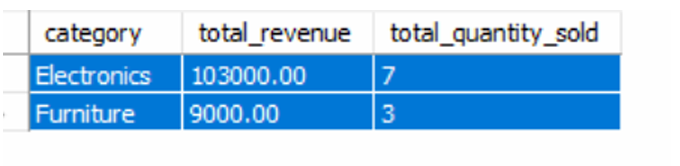

**Question 7**:

 The management observes that:

“Revenue is stable, but profit margins are shrinking.”

Using the given schema:

- Explain how you would investigate this using SQL.
- What queries would you run?
- Which tables would you analyze?
- What metrics would you compute?


**Answer:**

If revenue is stable but profit margins are shrinking, I would investigate whether the cost of products has increased, whether low-profit products are being sold in higher quantities, or whether the selling prices have decreased.

**Tables to Analyze**

Orders – To analyze overall sales and revenue.

Order_Items – To calculate revenue and quantity sold for each product.

Products – To compare cost price and selling price and calculate profit.

**Metrics to Compute**

- Total Revenue
- Total Cost
- Total Profit
- Profit Margin (%)
- Quantity Sold


In [ ]:
Query 1: Calculate Revenue, Cost, Profit, and Profit Margin
USE customer_db;
SELECT
    p.product_name,
    SUM(oi.quantity * oi.price) AS total_revenue,
    SUM(oi.quantity * p.cost_price) AS total_cost,
    SUM(oi.quantity * oi.price) - SUM(oi.quantity * p.cost_price) AS total_profit,
    ROUND(
        ((SUM(oi.quantity * oi.price) - SUM(oi.quantity * p.cost_price))
        / SUM(oi.quantity * oi.price)) * 100, 2
    ) AS profit_margin
FROM Products p
JOIN Order_Items oi
ON p.product_id = oi.product_id
GROUP BY p.product_name;

Query 2: Find Products with the Lowest Profit per Unit
SELECT
    product_name,
    selling_price,
    cost_price,
    (selling_price - cost_price) AS profit_per_unit
FROM Products
ORDER BY profit_per_unit ASC;


**Outputs:**

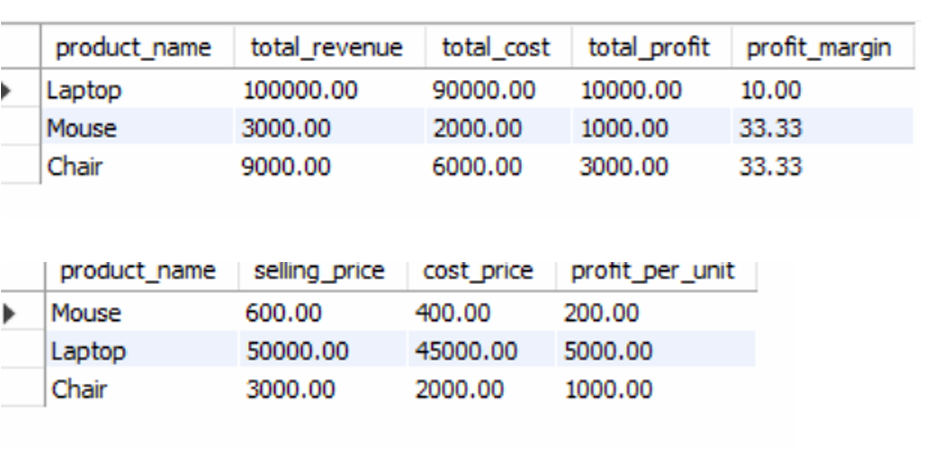

Conclusion

From the analysis, the Laptop generates the highest revenue but has the lowest profit margin (10%). This indicates that although revenue is stable, higher product costs or increased sales of lower-margin products can reduce overall profitability. Management can use this information to review pricing strategies, control costs, and focus on improving profit margins.


**Question 8:**

 Write a query to:

- Identify duplicate customers based on same name and city

- Show number of duplicate occurrences

Explain how you would clean such data.


**Answer:**

In [ ]:
USE customer_db;
INSERT INTO customers (customer_name, city, signup_date)
VALUES
('Neha', 'Bengaluru', '2026-06-25'),
('Rahul', 'Mysuru', '2026-06-24');
SELECT
    customer_name,
    city,
    COUNT(*) AS duplicate_occurrences
FROM customers
GROUP BY customer_name, city
HAVING COUNT(*) > 1;


**Output:**


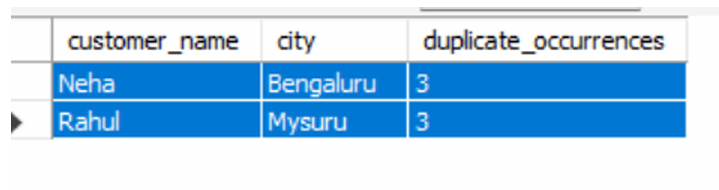

How would you clean such data?

- Identify duplicate records using GROUP BY and HAVING.
- Verify whether the duplicate records belong to the same customer.
- Keep one valid record and remove the duplicate records.
- Add a PRIMARY KEY or UNIQUE constraint to prevent future duplicates.
- Perform regular data validation before inserting new customer records.


**Question 9**:

a) What is a View?

b) How is it different from a Materialized View?

c) When should analytics teams prefer materialized views?

d) What are the risks of overusing views?


**Answer:**

a) What is a View?

-> A View is a virtual table created from the result of a SQL query. It does not store data itself; instead, it retrieves data from one or more underlying tables whenever it is queried.

b) How is it different from a Materialized View?

-> A View does not store data physically. It always retrieves the latest data from the base tables.
A Materialized View stores the query result physically on disk. It must be refreshed periodically to reflect changes in the underlying tables, but queries on it are usually faster.

c) When should analytics teams prefer Materialized Views?

-> Analytics teams should use Materialized Views when:
Queries involve large datasets and are executed frequently.
Reports and dashboards require faster query performance.
The data does not change continuously and can be refreshed at regular intervals.

d) What are the risks of overusing Views?

-> The risks of overusing Views include:

- Slower query performance due to multiple nested views.
- Increased complexity, making queries harder to understand and maintain.
- Higher database processing overhead.
- Difficulty in debugging and optimizing SQL queries.


**Question 10**:

The CEO asks:

“Identify customers whose monthly spending has consistently decreased over the last 3 months.”

You must:

- Describe the approach
- Mention which SQL features you would use (CTE, window functions, etc.)
- Explain how you would validate results


**Answer:**

Approach

To identify customers whose monthly spending has consistently decreased over the last three months, I would first calculate each customer's total spending for every month. Then, I would compare the monthly spending values to determine whether the spending has decreased month after month.

SQL Features Used

- CTE (Common Table Expression): To organize the query into smaller and more readable steps.
- Window Functions (LAG()): To compare the current month's spending with the previous month's spending.
- GROUP BY: To calculate the total monthly spending for each customer.
- SUM(): To calculate the total amount spent each month.
- ORDER BY: To arrange the monthly data in chronological order.

Validation of Results

To validate the results:

- Verify that monthly spending is calculated correctly for each customer.
- Ensure that data is available for all three consecutive months.
- Compare each month's spending with the previous month using the LAG() function.
Confirm that spending decreases consistently across all three months.
- Cross-check the results with the original Orders table to ensure accuracy before reporting.
